# Edge Pipeline — One Step per Cell
This notebook shows the **image after each transformation** in a separate cell, so you can see the sequence clearly.

**Sequence:**
1) Load (show)
2) Grayscale (show)
3) (Optional) Upscale for tiny screenshots (show)
4) CLAHE (show)
5) Bilateral filter (show)
6) Unsharp mask (show)
7) Auto Canny (show)
8) Manual Canny (show)
9) Dilate (show)
10) Close (show)
11) (Optional) Skeletonize (show)


## 0) Install dependencies

In [3]:
# !pip install opencv-python pillow matplotlib numpy

## 1) Imports & helpers

In [4]:
import cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

def show_img(img, title=None, gray=False, size=(6,10)):
    plt.figure(figsize=size)
    if title: plt.title(title)
    if gray:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off'); plt.show()

def skeletonize(binary):
    bin8 = (binary > 0).astype(np.uint8) * 255
    skel = np.zeros_like(bin8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    while True:
        eroded = cv2.erode(bin8, element)
        temp = cv2.dilate(eroded, element)
        temp = cv2.subtract(bin8, temp)
        skel = cv2.bitwise_or(skel, temp)
        bin8 = eroded.copy()
        if cv2.countNonZero(bin8) == 0:
            break
    return skel


## 2) Configure your image & settings

In [5]:
# Set your image path here
image_path = r'C:\Users\yemi\myratekard\veriry\WhatsApp Image 2025-10-13 at 8.51.21 PM.jpeg'  # change to your file

# Upscale toggle
USE_UPSCALE = True
UPSCALE_FACTOR = 3.0  # try 1.5 or 2.0

# CLAHE
CLAHE_clip = 2.5
CLAHE_tiles = (8,8)

# Bilateral filter settings
bilateral_d = 7
bilateral_sigmaC = 60
bilateral_sigmaS = 60

# Unsharp mask
unsharp_sigma = 1.0
unsharp_amount = 1.5

# Canny manual thresholds
CANNY_LOW = 40
CANNY_HIGH = 120

# Post-processing
DILATE_KERNEL = (5,5)
CLOSE_ITERS = 1
DO_SKELETON = True


## 3) Load — show image

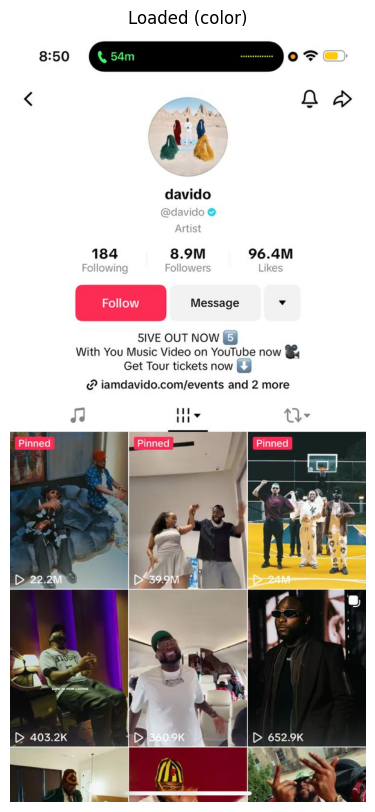

In [6]:
bgr = cv2.cvtColor(np.array(Image.open(image_path).convert('RGB')), cv2.COLOR_RGB2BGR)
show_img(bgr, 'Loaded (color)')


## 4) Grayscale — show image

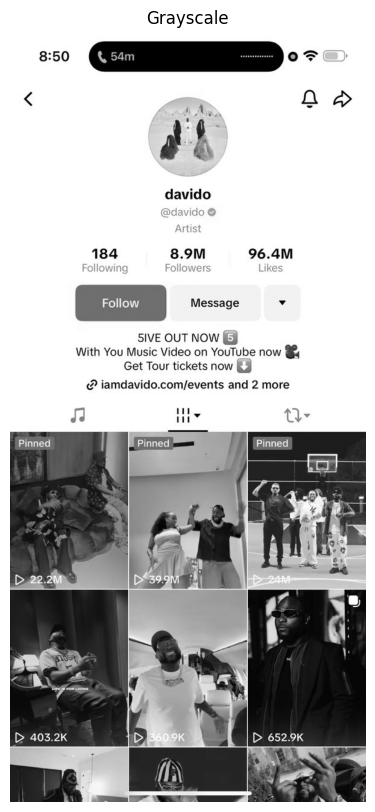

In [7]:
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
show_img(gray, 'Grayscale', gray=True)


## 5) (Optional) Upscale — show image

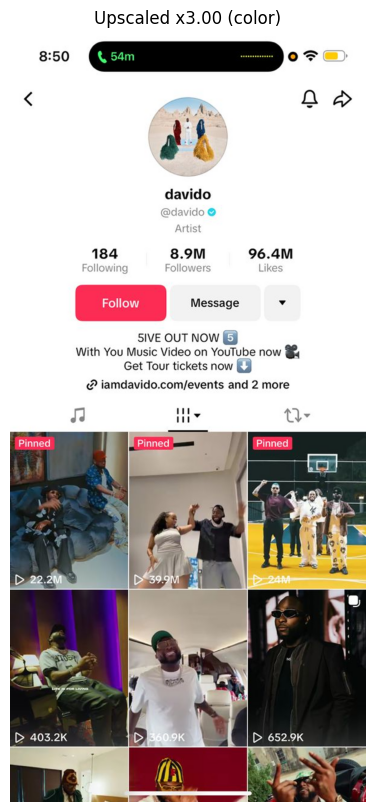

In [8]:
if USE_UPSCALE:
    bgr = cv2.resize(bgr, dsize=None, fx=UPSCALE_FACTOR, fy=UPSCALE_FACTOR, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    show_img(bgr, f'Upscaled x{UPSCALE_FACTOR:.2f} (color)')
else:
    print('Upscale disabled; skipping.')


## 6) CLAHE — show image

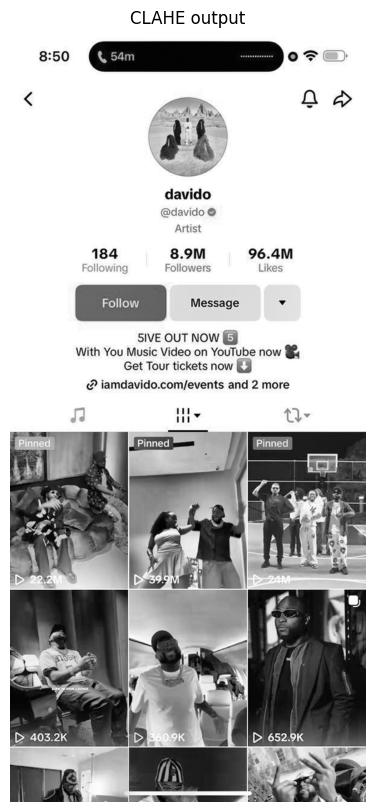

In [9]:
clahe = cv2.createCLAHE(clipLimit=CLAHE_clip, tileGridSize=CLAHE_tiles)
g1 = clahe.apply(gray)
show_img(g1, 'CLAHE output', gray=True)


## 7) Bilateral filter — show image

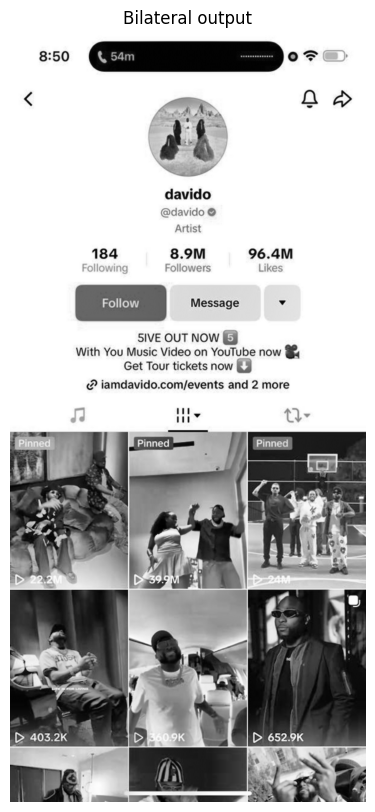

In [10]:
g2 = cv2.bilateralFilter(g1, d=bilateral_d, sigmaColor=bilateral_sigmaC, sigmaSpace=bilateral_sigmaS)
show_img(g2, 'Bilateral output', gray=True)


## 8) Unsharp mask — show image

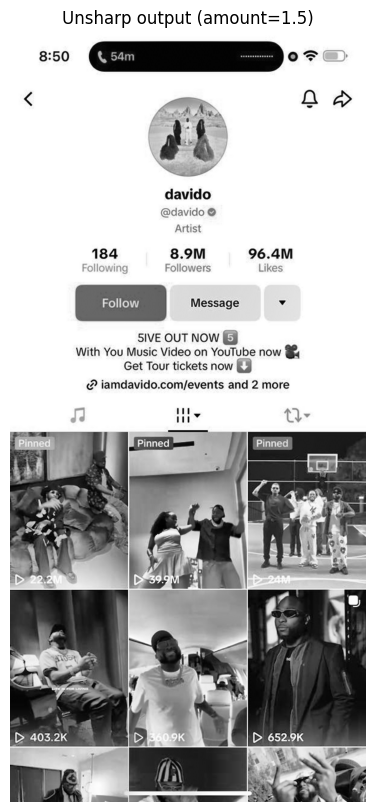

In [11]:
blur = cv2.GaussianBlur(g2, (0,0), sigmaX=unsharp_sigma)
g3 = cv2.addWeighted(g2, 1+unsharp_amount, blur, -unsharp_amount, 0)
show_img(g3, f'Unsharp output (amount={unsharp_amount})', gray=True)


## 9) Edges — Auto Canny — show image

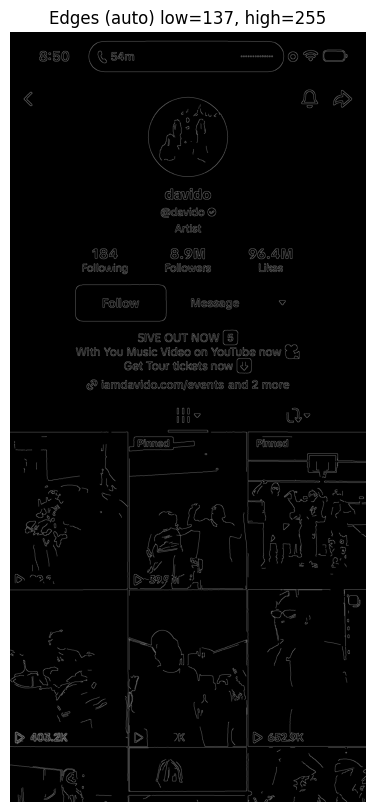

In [12]:
v = np.median(g3)
auto_low  = int(max(0, 0.66 * v))
auto_high = int(min(255, 1.33 * v))
edges_auto = cv2.Canny(g3, auto_low, auto_high, L2gradient=True)
show_img(edges_auto, f'Edges (auto) low={auto_low}, high={auto_high}', gray=True)


## 10) Edges — Manual Canny — show image

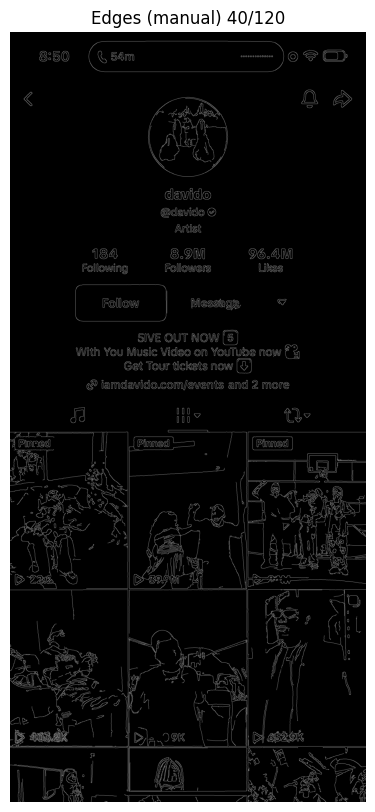

In [13]:
edges_manual = cv2.Canny(g3, CANNY_LOW, CANNY_HIGH, L2gradient=True)
show_img(edges_manual, f'Edges (manual) {CANNY_LOW}/{CANNY_HIGH}', gray=True)


## 11) Post — Dilate — show image

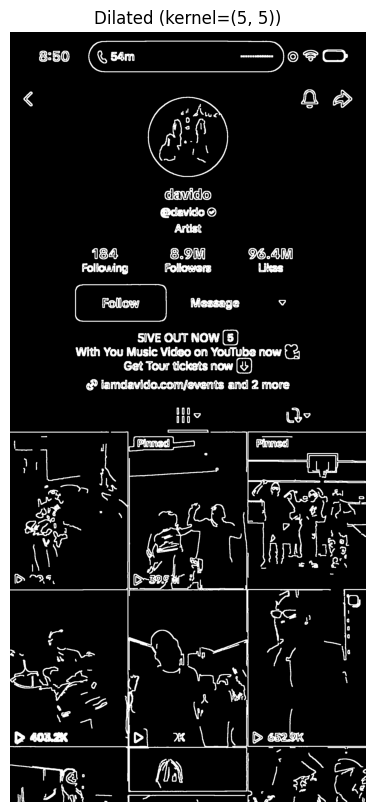

In [14]:
k = cv2.getStructuringElement(cv2.MORPH_RECT, DILATE_KERNEL)
dilated = cv2.dilate(edges_auto, k, iterations=1)
show_img(dilated, f'Dilated (kernel={DILATE_KERNEL})', gray=True)

## 12) Post — Close — show image

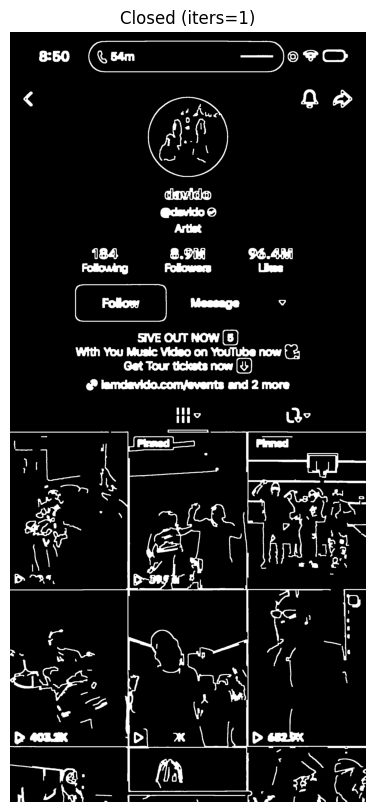

In [15]:
closed = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, k, iterations=CLOSE_ITERS)
show_img(closed, f'Closed (iters={CLOSE_ITERS})', gray=True)

## 13) Post — Skeletonize (optional) — show image

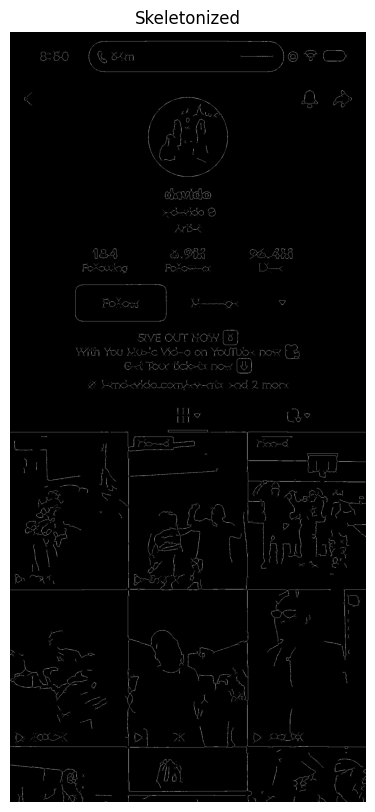

In [16]:
if DO_SKELETON:
    skel = skeletonize(closed)
    show_img(skel, 'Skeletonized', gray=True)
else:
    print('Skeletonize disabled; skipping.')


In [17]:
import cv2
import numpy as np

def detect_keypoints_from_edge(
    edge_img,
    scale_factor=1,
    contour_min_area=50,
    poly_epsilon_factor=0.02,
    hough_threshold=150,
    hough_min_line_length=100,
    hough_max_line_gap=20,
    duplicate_tol=5,
    point_radius=4
):
    """
    Detect keypoints (corners, centroids, line intersections) directly from an edge image
    and plot them on a black canvas.

    Parameters:
      - scale_factor: downscale to speed up (integer ≥ 1)
      - contour_min_area: minimum contour area to consider
      - poly_epsilon_factor: fraction of perimeter for contour corner approximation
      - hough_threshold, hough_min_line_length, hough_max_line_gap: for Hough line intersections
      - duplicate_tol: merge points that are this close (pixels)
      - point_radius: size of plotted points on the black canvas

    Returns:
      - unique_points: list of (x, y) keypoints (in original scale)
      - canvas: black image (same size) with points drawn
    """
    h_full, w_full = edge_img.shape[:2]

    # 1. Optional downscale for speed
    if scale_factor > 1:
        small = cv2.resize(edge_img, (w_full // scale_factor, h_full // scale_factor),
                           interpolation=cv2.INTER_AREA)
    else:
        small = edge_img.copy()

    # Ensure binary uint8 image
    if small.dtype != np.uint8:
        small = cv2.normalize(small, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(small, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    pts = []

    # 2. Contour-based keypoints
    contours, _ = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        if cv2.contourArea(cnt) < contour_min_area:
            continue
        eps = poly_epsilon_factor * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, eps, True)
        for p in approx:
            pts.append(tuple(p[0]))

        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx, cy = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
            pts.append((cx, cy))

    # 3. Line-based intersections
    horizontals, verticals = [], []
    lines = cv2.HoughLinesP(binary, 1, np.pi / 180,
                            threshold=hough_threshold,
                            minLineLength=hough_min_line_length,
                            maxLineGap=hough_max_line_gap)
    if lines is not None:
        for (x1, y1, x2, y2) in lines[:, 0]:
            dx, dy = abs(x2 - x1), abs(y2 - y1)
            if dx > 2 * dy:
                horizontals.append((x1, y1, x2, y2))
            elif dy > 2 * dx:
                verticals.append((x1, y1, x2, y2))

        def intersect(l1, l2):
            x1, y1, x2, y2 = l1
            x3, y3, x4, y4 = l2
            denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
            if abs(denom) < 1e-6:
                return None
            px = ((x1*y2 - y1*x2)*(x3 - x4) - (x1 - x2)*(x3*y4 - y3*x4)) / denom
            py = ((x1*y2 - y1*x2)*(y3 - y4) - (y1 - y2)*(x3*y4 - y3*x4)) / denom
            return (int(px), int(py))

        for h in horizontals:
            for v in verticals:
                p = intersect(h, v)
                if p:
                    pts.append(p)

    # 4. Deduplicate nearby points
    unique = []
    for (x, y) in pts:
        if not any(abs(x - ux) < duplicate_tol and abs(y - uy) < duplicate_tol for ux, uy in unique):
            unique.append((x, y))

    # 5. Rescale to original dimensions
    if scale_factor > 1:
        unique = [(x * scale_factor, y * scale_factor) for (x, y) in unique]

    # 6. Plot on black canvas
    canvas = np.zeros((h_full, w_full, 3), dtype=np.uint8)
    for (x, y) in unique:
        if 0 <= x < w_full and 0 <= y < h_full:
            cv2.circle(canvas, (int(x), int(y)), point_radius, (0, 255, 0), -1)

    return unique, canvas


In [27]:
points, canvas = detect_keypoints_from_edge(
    dilated,
    scale_factor=1,
    contour_min_area=900,
    poly_epsilon_factor=0.03,
    hough_threshold=180,
    hough_min_line_length=320,
    hough_max_line_gap=25,
    duplicate_tol=10,
    point_radius=3
)


C:\Users\yemi\AppData\Local\Temp\ipykernel_53744\3193829103.py:83: RuntimeWarning: overflow encountered in scalar multiply
  py = ((x1*y2 - y1*x2)*(y3 - y4) - (y1 - y2)*(x3*y4 - y3*x4)) / denom
C:\Users\yemi\AppData\Local\Temp\ipykernel_53744\3193829103.py:83: RuntimeWarning: overflow encountered in scalar subtract
  py = ((x1*y2 - y1*x2)*(y3 - y4) - (y1 - y2)*(x3*y4 - y3*x4)) / denom


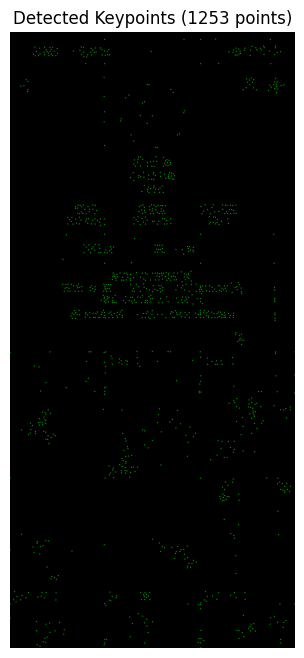

In [28]:
import matplotlib.pyplot as plt

# Assuming you've already run:
# points, canvas = detect_keypoints_from_edge(edge_img)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Keypoints ({len(points)} points)")
plt.axis('off')
plt.show()


In [31]:
from sklearn.cluster import DBSCAN
import numpy as np

def cluster_points(points, eps=12, min_samples=4):
    if not points: 
        return []
    X = np.array(points)
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    keep = []
    for lab in set(labels):
        if lab == -1:  # noise
            continue
        cluster = X[labels == lab]
        cx, cy = cluster.mean(axis=0)
        keep.append((int(cx), int(cy)))
    return keep


import cv2
import numpy as np

def draw_points_on_canvas(points, image_shape, color=(0, 255, 0), radius=4):
    """
    Redraws a black canvas with keypoints.

    Args:
      points: list of (x, y) coordinates
      image_shape: tuple (H, W) — same as the edge image shape
      color: BGR color for points (default = green)
      radius: point radius (in pixels)

    Returns:
      canvas: np.ndarray (H, W, 3)
    """
    h, w = image_shape[:2]
    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    for (x, y) in points:
        if 0 <= x < w and 0 <= y < h:
            cv2.circle(canvas, (int(x), int(y)), radius, color, -1)
    return canvas



# Suppose you clustered the original points:
points_filtered = cluster_points(points, eps=12, min_samples=5)

# Redraw canvas
canvas_new = draw_points_on_canvas(points_filtered, dilated.shape, color=(0,255,0), radius=3)


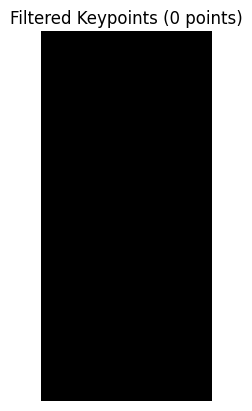

In [32]:
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(canvas_new, cv2.COLOR_BGR2RGB))
plt.title(f"Filtered Keypoints ({len(points_filtered)} points)")
plt.axis('off')
plt.show()


In [19]:
def downsize(img_array: np.ndarray, scale: float) -> np.ndarray:
    """
    Resize the image by the given scale factor.
    scale < 1 shrinks, >1 enlarges.
    """
    h, w = img_array.shape[:2]
    new_w = int(w * scale)
    new_h = int(h * scale)
    # Choose interpolation: INTER_AREA is good for shrinking
    resized = cv2.resize(img_array, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized

In [20]:
import numpy as np

with open("array_dump.txt", "w") as f:
    s = np.array2string(downsize(dilated,0.1), threshold=np.inf, max_line_width=np.inf)
    f.write(s)

In [ ]:
# Instagram vs Not-Instagram using ONLY the TOP HALF of each image
# ---------------------------------------------------------------
# data/
#   instagram/
#   non_instagram/

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# Config
# -----------------------------
DATA_DIR   = "data"
IMG_SIZE   = (256, 256)     # model input size after crop+resize
BATCH_SIZE = 8
VAL_SPLIT  = 0.2
EPOCHS     = 30
MODEL_PATH = "ig_tophalf_cnn.h5"
AUTOTUNE   = tf.data.AUTOTUNE

# -----------------------------
# Load dataset (whole images)
# -----------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, labels="inferred", label_mode="int",
    validation_split=VAL_SPLIT, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, labels="inferred", label_mode="int",
    validation_split=VAL_SPLIT, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# -----------------------------
# Crop TOP HALF only
# -----------------------------
def crop_top_half_batch(images, labels):
    h = tf.shape(images)[1]
    top = images[:, : (h // 2), :, :]                # keep top half
    top = tf.image.resize(top, IMG_SIZE)             # back to model size
    return top, labels

train_ds = train_ds.map(crop_top_half_batch, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(crop_top_half_batch,   num_parallel_calls=AUTOTUNE)

# -----------------------------
# Data augmentation (tiny data helper)
# -----------------------------
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def augment_batch(x, y):
    return augment(x, training=True), y

train_ds = train_ds.map(augment_batch, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

# -----------------------------
# Small CNN
# -----------------------------
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Dropout(0.3)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# -----------------------------
# Train (early stopping)
# -----------------------------
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)
]
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

# -----------------------------
# Evaluate + save
# -----------------------------
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation accuracy: {val_acc:.3f}")
model.save(MODEL_PATH)
print(f"Saved to {MODEL_PATH}")

# -----------------------------
# Predict on a single image (TOP HALF only)
# -----------------------------
def predict_image_tophalf(path):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    x = tf.keras.utils.img_to_array(img)[None, ...]   # (1,H,W,3) already resized by load_img
    # Emulate the top-half crop step:
    H = tf.shape(x)[1]
    x_top = x[:, : (H // 2), :, :]
    x_top = tf.image.resize(x_top, IMG_SIZE)
    prob = float(model.predict(x_top, verbose=0)[0][0])
    return prob  # P(instagram)

# Example:
# p = predict_image_tophalf("data/instagram/example.jpg")
# print("P(instagram) =", round(p, 3))
